In [22]:
import numpy as np
import matplotlib.pyplot as plt
from visualization import draw_field_with_robot
from particle_filter import *
from Localization_metrics import *

## Настройка параметров модели фильтра частиц

In [23]:
particles_count = 5000  # hyperparam: particles count 

# landmark coords
left_coord = Coord(-1, 5)
right_coord = Coord(1, 5)
lm = LandMark(left_coord, right_coord)

# standard deviation of noise for each dimension (x, y, theta)
system_noise = State(0.4, 0.4, 0.4)
sens_noise = np.array([0.05, 0.05, 0.05])

# initial state
state0 = State(0, 0, np.pi/2)

pf = ParticleFilter(particles_count, state0, lm, system_noise, sens_noise)
local_metrics = LocalizationMetrics()

## Хождение робота на поле

In [24]:
from IPython.display import clear_output, display
import matplotlib.pyplot as plt

# steps_cnt = int(input())
# trajectory = [(pf.state.x, pf.state.y)]

# fig, ax = plt.subplots(figsize=(8, 10))
# draw_field_with_robot(pf.state, pf.particles, ax=ax)
# display(fig)

# for i in range(steps_cnt):
#     step = State(*map(float, input().split()))
#     est_state = pf.simulate(step)
    
#     local_metrics.update(pf.ideal_state, est_state)
#     trajectory.append((est_state.x, est_state.y))

#     draw_field_with_robot(est_state, pf.particles, ax=ax)

#     traj = np.array(trajectory)
#     ax.plot(traj[:, 0], traj[:, 1], color='red', linewidth=2)   # от стартовой точки
#     ax.plot(traj[:, 0], traj[:, 1], 'ko', markersize=3)          # узловые точки пути

#     clear_output(wait=True)
#     display(fig)

#     # print("estimated state: ", est_state)
#     # print("true state: ", pf.state)

# plt.close(fig)

# res = local_metrics.summary()

In [25]:
# # метрики оценки качества локализации
# res

## Эксперменты

#### Насколько сильно шум движения ухудшает локализацию без PF?
#### Насколько PF компенсирует эту ошибку?
#### Как качество PF зависит от шума сенсора и количества частиц?

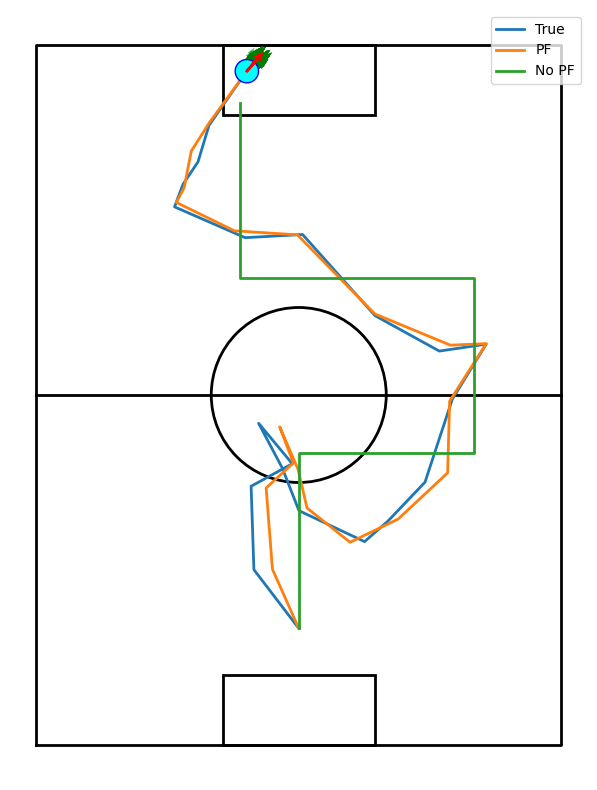

In [26]:
# насколько PF определяет фактическое положение робота
state0 = State(0, -4, np.pi / 2)
pf = ParticleFilter(particles_count, state0, lm, system_noise, sens_noise)

pf_metrics = LocalizationMetrics()
no_pf_metrics = LocalizationMetrics()

# ethalon trajectory
steps = [
    # ↑ к воротам
    State(1, 0, 0),
    State(1, 0, 0),
    State(1, 0, 0),

    # → вправо
    State(0, 0, -np.pi / 2),
    State(1, 0, 0),
    State(1, 0, 0),
    State(1, 0, 0),

    # ↑
    State(0, 0, np.pi / 2),
    State(1, 0, 0),
    State(1, 0, 0),
    State(1, 0, 0),

    # ←
    State(0, 0, np.pi / 2),
    State(1, 0, 0),
    State(1, 0, 0),
    State(1, 0, 0),
    State(1, 0, 0),

    # ↑ к воротам
    State(0, 0, -np.pi / 2),
    State(1, 0, 0),
    State(1, 0, 0),
    State(1, 0, 0),
]

fig, ax = plt.subplots(figsize=(8, 10))
draw_field_with_robot(pf.state, pf.particles, ax=ax)
display(fig)

true_trajectory = [(pf.state.x, pf.state.y)]
pf_trajectory = [(pf.state.x, pf.state.y)]
no_pf_trajectory = [(pf.no_pf_state.x, pf.no_pf_state.y)]

for step_i in steps:

    est_state = pf.simulate(step_i)
    pf_metrics.update(pf.state, est_state)
    no_pf_metrics.update(pf.state, pf.no_pf_state)

    true_trajectory.append((pf.state.x, pf.state.y))
    pf_trajectory.append((est_state.x, est_state.y))
    no_pf_trajectory.append((pf.no_pf_state.x, pf.no_pf_state.y))

    draw_field_with_robot(est_state, pf.particles, ax=ax)

    true_traj = np.array(true_trajectory)
    pf_traj = np.array(pf_trajectory)
    no_pf_traj = np.array(no_pf_trajectory)

    ax.plot(true_traj[:, 0], true_traj[:, 1], linewidth=2, label='True') # реальное состояние с шумом
    ax.plot(pf_traj[:, 0], pf_traj[:, 1], linewidth=2, label='PF') # оценка PF
    ax.plot(no_pf_traj[:, 0], no_pf_traj[:, 1], linewidth=2, label='No PF') # движение только по командам

    ax.legend()

    clear_output(wait=True)
    display(fig)

plt.close(fig)

res_pf = pf_metrics.summary()
res_no_pf = no_pf_metrics.summary()

In [27]:
res_pf

{'position_rmse': np.float64(0.20421204499952775),
 'position_mae': np.float64(0.16429372854723795),
 'position_max': np.float64(0.4196591602658737),
 'position_final': np.float64(0.033645521573245074),
 'angle_rmse': np.float64(0.0499707524379926)}

In [28]:
res_no_pf

{'position_rmse': np.float64(1.3803119117882567),
 'position_mae': np.float64(1.2693239497137856),
 'position_max': np.float64(2.40734359274323),
 'position_final': np.float64(0.5325953070772376),
 'angle_rmse': np.float64(0.7355005338122717)}